参考: Dao, "FlashAttention-2: Towards Better Parallelism and Workload Balancing"
      arXiv:2307.08691
      
相对 V1 的关键升级:

  1. exp -> exp2 优化: 用 tl.math.exp2 + log2(e) 缩放, 比 exp 快

  2. 软件流水线: num_stages=2/3/4, 让 K/V 加载和 QK matmul 重叠

  3. K 块直接 layout 成 (HEAD_DIM, BLOCK_N), 去掉 tl.trans

  4. autotune: sweep BLOCK_M/BLOCK_N/num_warps/num_stages

  5. Causal 支持: 显式 STAGE 常量, 编译器生成两套代码

  6. LSE 输出: m_i + log(l_i), 给 backward 用   

In [1]:
import torch
import triton
import triton.language as tl
import math
from typing import Optional, Tuple

In [2]:
# log2(e) 用于把 exp 转换成 exp2 (硬件上有 ex2 指令, 比 exp 快)
LOG2E = 1.4426950408889634

In [3]:
def _get_autotune_configs():
    configs = []
    for bm in [64, 128]:
        for bn in [32, 64, 128]:
            for nw in [4, 8]:
                for ns in [2, 3, 4]:
                    configs.append(
                        triton.Config(
                            {'BLOCK_M': bm, 'BLOCK_N': bn},
                            num_warps=nw,
                            num_stages=ns,
                        )
                    )
    return configs

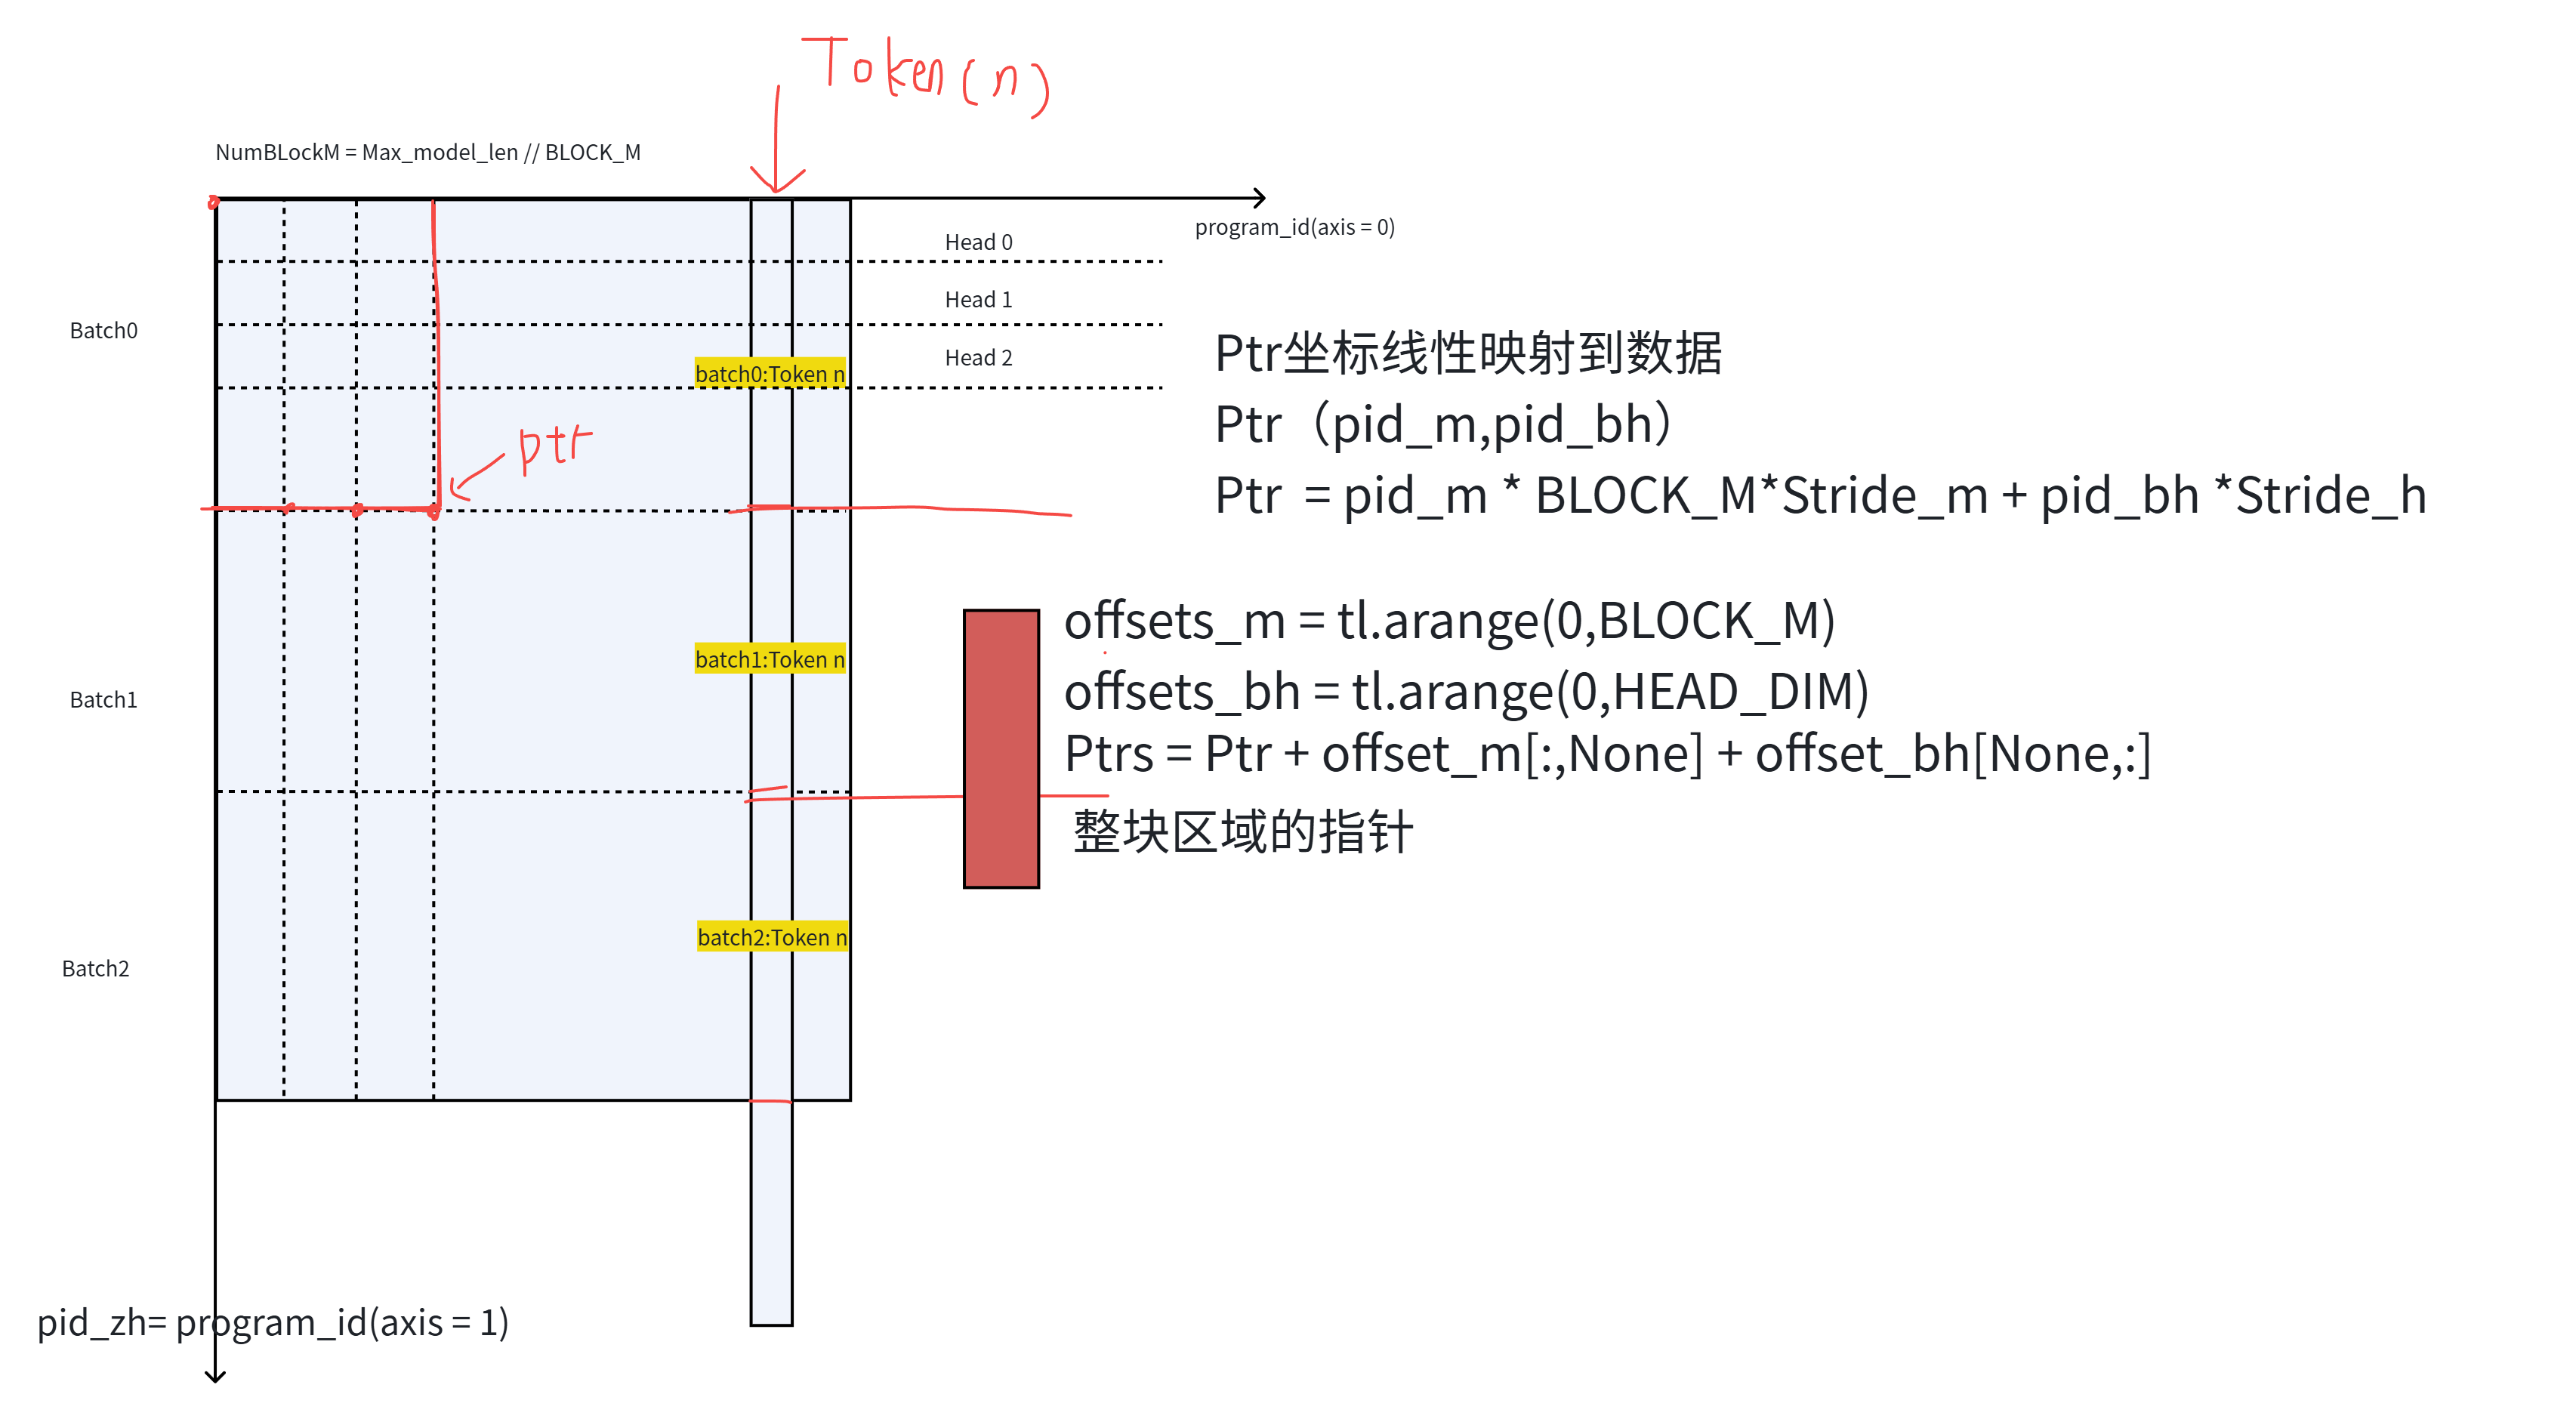

In [4]:
@triton.autotune(
    configs=_get_autotune_configs(),
    key=['N_CTX', 'HEAD_DIM', 'STAGE', 'IS_FP16'],
)
@triton.jit
def _flash_attn_v2_fwd_kernel(
    Q, K, V, O, LSE,
    softmax_scale_log2e,                  # = softmax_scale * log2(e), 预乘好
    stride_qb, stride_qh, stride_qm, stride_qd,
    stride_kb, stride_kh, stride_kn, stride_kd,
    stride_vb, stride_vh, stride_vn, stride_vd,
    stride_ob, stride_oh, stride_om, stride_od,
    stride_lz, stride_lh, stride_lm,
    
    N_CTX: tl.constexpr,                 # 实际序列长度 = MaxModelLen
    HEAD_DIM: tl.constexpr,               # 头维度 (constexpr) Hidden_size / head_num
    STAGE: tl.constexpr,                  # 1=causal因果注意力机制和全注意力机制
    IS_FP16: tl.constexpr,                # 输入 dtype flag
    HAVE_LSE:tl.constexpr,  
    BLOCK_M: tl.constexpr,                #读取Q时 [BLOCK_M,HEAD_DIM]
    BLOCK_N: tl.constexpr,                #读取KV时 [BLOCK_N,HEAD_DIM]
):
    pid_m  = tl.program_id(0)            # Q 块索引
    pid_bh = tl.program_id(1)            # batch * head 索引 (合并)
    # 关键: offset 只含 (batch, head) base, 不含 m 维
    # m 维交给 offs_m 统一处理, 每个维度只出现一次
    q_offset   = pid_bh * stride_qh
    o_offset   = pid_bh * stride_oh
    lse_offset = pid_bh * stride_lh
    kv_offset  = pid_bh * stride_kh
    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)         # (BLOCK_M,)
    offs_n = tl.arange(0, BLOCK_N)                            # (BLOCK_N,)
    offs_d = tl.arange(0, HEAD_DIM)                           # (HEAD_DIM,)
    # 显式写出所有 stride, 不依赖 D 维 stride=1
    q_ptrs = (Q + q_offset
              + offs_m[:, None] * stride_qm
              + offs_d[None, :] * stride_qd)
    q = tl.load(q_ptrs, mask=offs_m[:, None] < N_CTX, other=0.0)
    
    # 初始化OnlineSoftmax
    m_i = tl.full((BLOCK_M,),-float('inf'),dtype = tl.float32)
    l_i = tl.zeros((BLOCK_M,),dtype=tl.float32)    #sum累加
    acc = tl.zeros((BLOCK_M,HEAD_DIM),dtype=tl.float32)
    # 因果注意力&全注意力
    if STAGE == 1:
        hi_M = min(N_CTX, (pid_m + 1) * BLOCK_M)
    else:
        hi_M = N_CTX
    hi_aligned = (hi_M // BLOCK_N) * BLOCK_N
    for start_n in range(0, hi_aligned, BLOCK_N):
        start_n = tl.multiple_of(start_n, BLOCK_N)
        cur_offs_n = start_n + offs_n
        # Load K as (BLOCK_N, HEAD_DIM) — 推荐调整存储布局
        k_ptrs = K + kv_offset + cur_offs_n[:, None] * stride_kn + offs_d[None, :] * stride_kd
        k = tl.load(k_ptrs)
        
        # Load V as (BLOCK_N, HEAD_DIM)
        v_ptrs = V + kv_offset + cur_offs_n[:, None] * stride_vn + offs_d[None, :] * stride_vd
        v = tl.load(v_ptrs)
        
        qk = tl.dot(q, tl.trans(k)) * softmax_scale_log2e  # (BM, BN)
        
        #QK进行softmax，以及因果掩码
        if STAGE == 1:
            # 下三角: query_idx >= key_idx 才保留
            causal_mask = offs_m[:, None] >= cur_offs_n[None, :]
            qk = tl.where(causal_mask, qk, -float("inf"))
        #axis = 1 的维度是token 
        m_ij = tl.max(qk,axis = 1)
        m_new = tl.maximum(m_i,m_ij)
        alpha = tl.math.exp2(m_i - m_new)
        #2^(x - old) * 2 (old - new) = 2^(x-new)
        p = tl.math.exp2(qk-m_new[:,None])
        # 广播机制 tokenmax 应该在axis = 0的维度排布
        l_i = l_i * alpha + tl.sum(p,axis = 1)
        if IS_FP16:
            p_typed = p.to(tl.float16)
        else:
            p_typed = p.to(tl.bfloat16)
            
        acc = acc * alpha[:, None]                          # 旧 acc 缩放
        acc = tl.dot(p_typed, v, acc)                       # MMA 累加
        m_i = m_new 
    acc = acc /l_i[:,None]
    o_ptrs = (O + o_offset + offs_m[:,None]*stride_om+offs_d[None,:]*stride_od)
    if IS_FP16:
        o_typed = acc.to(tl.float16)
    else:
        o_typed = acc.to(tl.bfloat16)
    tl.store(o_ptrs, o_typed, mask=offs_m[:, None] < N_CTX)
    #
    if HAVE_LSE:
        lse = m_i + tl.log(l_i)
        lse_ptrs = LSE + lse_offset + offs_m * stride_lm
        tl.store(lse_ptrs, lse, mask=offs_m < N_CTX)

In [5]:
def flash_attention_v2(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    causal: bool = False,
    softmax_scale: Optional[float] = None,
    return_lse: bool = False,
) -> torch.Tensor | Tuple[torch.Tensor, torch.Tensor]:

    """
    FlashAttention V2 (Forward only).
    Args:
        q: Query tensor, shape (B, H, N_CTX, HEAD_DIM), dtype fp16/bf16, contiguous
        k: Key tensor,   shape (B, H, N_CTX, HEAD_DIM), dtype fp16/bf16, contiguous
        v: Value tensor, shape (B, H, N_CTX, HEAD_DIM), dtype fp16/bf16, contiguous
        causal: 是否使用 causal mask
        softmax_scale: attention scale, 默认 1/sqrt(HEAD_DIM)
        return_lse: 是否同时返回 LSE (log-sum-exp), backward 需要
    Returns:
        out: shape (B, H, N_CTX, HEAD_DIM)
        lse (optional): shape (B, H, N_CTX), fp32
    """
    # --- 1. 输入检查 ---
    assert q.is_cuda and k.is_cuda and v.is_cuda, "q/k/v must be on CUDA"
    assert q.dtype in (torch.float16, torch.bfloat16), \
        f"q dtype must be fp16/bf16, got {q.dtype}"
    assert k.dtype == q.dtype and v.dtype == q.dtype, "q/k/v must have same dtype"
    assert q.is_contiguous(), "q must be contiguous (B, H, N, D)"
    assert k.is_contiguous(), "k must be contiguous (B, H, N, D)"
    assert v.is_contiguous(), "v must be contiguous (B, H, N, D)"
    B, H, N_CTX, HEAD_DIM = q.shape
    assert k.shape == q.shape, f"k shape mismatch: {tuple(k.shape)} != {tuple(q.shape)}"
    assert v.shape == q.shape, f"v shape mismatch: {tuple(v.shape)} != {tuple(q.shape)}"
    assert HEAD_DIM in (16, 32, 64, 128, 256), \
        f"HEAD_DIM must be power of 2 in (16, 32, 64, 128, 256), got {HEAD_DIM}"
    # --- 2. 参数准备 ---
    if softmax_scale is None:
        softmax_scale = 1.0 / math.sqrt(HEAD_DIM)
    softmax_scale_log2e = softmax_scale * LOG2E
    is_fp16 = (q.dtype == torch.float16)
    # --- 3. 分配输出 ---
    o = torch.empty_like(q)
    # LSE: return_lse=True 时分配, False 时传 None
    # kernel 里有 HAVE_LSE constexpr 控制, 不会访问 None
    if return_lse:
        lse = torch.empty((B, H, N_CTX), device=q.device, dtype=torch.float32)
    else:
        lse = None   # ← 关键: 不用 q 充数, 避免覆盖 Q 的数据
    # --- 4. Block size 选择 ---
    # 生产环境应该用 autotune sweep, 这里给个合理的 default
    # 经验值: BLOCK_M 越大, Q 块数越多, 并行度越好
    #        BLOCK_N 越小, SRAM 压力小, 但循环次数多
    BLOCK_M = 128 if N_CTX >= 512 else 64
    BLOCK_N = 64 if HEAD_DIM <= 64 else 32
    # --- 5. Grid ---
    grid = (triton.cdiv(N_CTX, BLOCK_M), B * H)
    # --- 6. Launch kernel ---
    # LSE stride: return_lse=True 时用 lse 的 stride, False 时传 0
    # 配合 HAVE_LSE constexpr, kernel 会跳过 LSE store
    if return_lse:
        lse_z, lse_h, lse_m = lse.stride(0), lse.stride(1), lse.stride(2)
    else:
        lse_z, lse_h, lse_m = 0, 0, 0   # dummy strides, 不会被访问
    _flash_attn_v2_fwd_kernel[grid](
        q, k, v, o, lse,
        softmax_scale_log2e,
        q.stride(0), q.stride(1), q.stride(2), q.stride(3),
        k.stride(0), k.stride(1), k.stride(2), k.stride(3),
        v.stride(0), v.stride(1), v.stride(2), v.stride(3),
        o.stride(0), o.stride(1), o.stride(2), o.stride(3),
        lse_z, lse_h, lse_m,
        N_CTX=N_CTX,
        HEAD_DIM=HEAD_DIM,
        STAGE=1 if causal else 2,
        IS_FP16=is_fp16,
        HAVE_LSE=return_lse,
        # BLOCK_M=BLOCK_M,
        # BLOCK_N=BLOCK_N,
    )
    if return_lse:
        return o, lse
    return o



# =============================================================================

# 参考实现 (PyTorch) - 用于验证

# =============================================================================

def reference_attention(

    q: torch.Tensor,

    k: torch.Tensor,

    v: torch.Tensor,

    causal: bool = False,

    softmax_scale: Optional[float] = None,

) -> torch.Tensor:

    """标准 PyTorch attention, 作为 ground truth."""

    B, H, N, D = q.shape

    if softmax_scale is None:

        softmax_scale = 1.0 / math.sqrt(D)


    qk = torch.matmul(q, k.transpose(-2, -1)) * softmax_scale

    if causal:

        mask = torch.tril(torch.ones(N, N, device=q.device, dtype=torch.bool))

        qk = qk.masked_fill(~mask, float("-inf"))


    p = torch.softmax(qk, dim=-1)

    return torch.matmul(p, v)



# =============================================================================

# 验证 + Benchmark

# =============================================================================

def verify(

    B: int = 2, H: int = 4, N: int = 256, D: int = 64,

    dtype: torch.dtype = torch.float16, causal: bool = True,

) -> bool:

    """正确性验证: Triton vs PyTorch."""

    torch.manual_seed(0)

    device = "cuda"


    q = torch.randn(B, H, N, D, device=device, dtype=dtype)

    k = torch.randn(B, H, N, D, device=device, dtype=dtype)

    v = torch.randn(B, H, N, D, device=device, dtype=dtype)


    out = flash_attention_v2(q, k, v, causal=causal)

    ref = reference_attention(q, k, v, causal=causal)


    max_abs_err = (out.float() - ref.float()).abs().max().item()

    max_rel_err = ((out.float() - ref.float()).abs()

                   / (ref.float().abs() + 1e-6)).max().item()

    print(f"  max abs err = {max_abs_err:.4e}, "

          f"max rel err = {max_rel_err:.4e}")


    # fp16/bf16 下 < 5e-3 算通过

    passed = max_abs_err < 5e-3

    status = "✅ Passed" if passed else "❌ Failed"

    print(f"  {status} (causal={causal}, dtype={dtype})")

    return passed






In [6]:

def benchmark(

    B: int = 4, H: int = 16, N: int = 4096, D: int = 128,

    dtype: torch.dtype = torch.float16,

):

    """性能 benchmark: Triton vs PyTorch."""

    import time

    device = "cuda"


    q = torch.randn(B, H, N, D, device=device, dtype=dtype)

    k = torch.randn(B, H, N, D, device=device, dtype=dtype)

    v = torch.randn(B, H, N, D, device=device, dtype=dtype)


    flops = 4 * B * H * N * N * D / 1e9

    print(f"\n[Benchmark] B={B}, H={H}, N={N}, D={D}, dtype={dtype}")

    print(f"[Benchmark] FLOPs per iter: {flops:.2f} GFLOPs")


    for causal in [False, True]:

        # Warmup

        for _ in range(3):

            _ = flash_attention_v2(q, k, v, causal=causal)

        torch.cuda.synchronize()


        t0 = time.time()

        for _ in range(10):

            _ = flash_attention_v2(q, k, v, causal=causal)

        torch.cuda.synchronize()

        t_flash = (time.time() - t0) / 10 * 1e3


        for _ in range(3):

            _ = reference_attention(q, k, v, causal=causal)

        torch.cuda.synchronize()

        t0 = time.time()

        for _ in range(10):

            _ = reference_attention(q, k, v, causal=causal)

        torch.cuda.synchronize()

        t_ref = (time.time() - t0) / 10 * 1e3


        tflops_flash = flops / t_flash

        tflops_ref = flops / t_ref

        print(f"[Benchmark] causal={causal:5}: "

              f"flash={t_flash:6.2f} ms ({tflops_flash:5.1f} TFLOPs) | "

              f"ref={t_ref:6.2f} ms ({tflops_ref:5.1f} TFLOPs) | "

              f"speedup={t_ref / t_flash:.2f}x")



In [7]:
print("=" * 60)
print("FlashAttention V2 (Production) - 验证 + Benchmark")
print("=" * 60)
print("\n[Verify] fp16 non-causal:")
verify(B=2, H=4, N=128, D=64, dtype=torch.float16, causal=False)
print("\n[Verify] fp16 causal:")
verify(B=2, H=4, N=128, D=64, dtype=torch.float16, causal=True)
print("\n[Verify] bf16 causal:")
verify(B=2, H=4, N=128, D=64, dtype=torch.bfloat16, causal=True)
print("\n[Verify] LSE output:")
q = torch.randn(2, 4, 128, 64, device="cuda", dtype=torch.float16)
k = torch.randn_like(q)
v = torch.randn_like(q)
out, lse = flash_attention_v2(q, k, v, causal=False, return_lse=True)
print(f"  out.shape = {out.shape}, lse.shape = {lse.shape}")
print(f"  out.dtype = {out.dtype}, lse.dtype = {lse.dtype}")
print("  ✅ LSE output works")
if torch.cuda.is_available():
    print("\n[Benchmark] config:")
    benchmark(B=4, H=8, N=1024, D=128, dtype=torch.float16)
else:
    print("\n[Benchmark] CUDA not available, skip")

FlashAttention V2 (Production) - 验证 + Benchmark

[Verify] fp16 non-causal:
  max abs err = 9.7656e-04, max rel err = 8.2002e+00
  ✅ Passed (causal=False, dtype=torch.float16)

[Verify] fp16 causal:
  max abs err = 1.9531e-03, max rel err = 3.1099e+01
  ✅ Passed (causal=True, dtype=torch.float16)

[Verify] bf16 causal:
  max abs err = 1.5625e-02, max rel err = 3.3922e+02
  ❌ Failed (causal=True, dtype=torch.bfloat16)

[Verify] LSE output:
  out.shape = torch.Size([2, 4, 128, 64]), lse.shape = torch.Size([2, 4, 128])
  out.dtype = torch.float16, lse.dtype = torch.float32
  ✅ LSE output works

[Benchmark] config:

[Benchmark] B=4, H=8, N=1024, D=128, dtype=torch.float16
[Benchmark] FLOPs per iter: 17.18 GFLOPs
[Benchmark] causal=    0: flash=  0.51 ms ( 34.0 TFLOPs) | ref=  1.73 ms (  9.9 TFLOPs) | speedup=3.43x
[Benchmark] causal=    1: flash=  0.17 ms (102.8 TFLOPs) | ref=  3.00 ms (  5.7 TFLOPs) | speedup=17.93x
